### Assignment Code: DA-AG-018 
# Anomaly Detection & Time Series Assignment

1. What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.
  - Anomaly Detection is the process of identifying unusual or abnormal data that does not follow normal patterns. These unusual observations are called anomalies or outliers.
  - It is used in fraud detection, healthcare, cybersecurity, and fault detection.
  - There are three main types of anomalies:
     - 1. Point Anomaly - A single data point that is very different from the rest of the data.
        - E.g. If daily temperatures are: 30°C, 31°C, 32°C, 85°C, 30°C ,here 85°C is a point anomaly.
     - 2. Contextual Anomaly - A data point that is abnormal only in a specific context such as time or season.
         - E.g. 40°C is normal in summer but abnormal in winter.
     - 3. Collective Anomaly - A group of data points together behaves abnormally, even if individual values seem normal.
         - E.g. Thousands of login requests at the same time may indicate a cyberattack.

2. Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.
  - Isolation Forest, DBSCAN, and Local Outlier Factor (LOF) are commonly used techniques for anomaly detection, but each works in a different way and is suitable for different types of data.

     - Isolation Forest detects anomalies by randomly splitting the data into smaller parts. Since anomalous points are rare and very different from normal data, they get isolated much faster. It works well with large and high-dimensional datasets, so it is often used in fraud detection, cybersecurity, and large-scale monitoring systems.

     - DBSCAN is a density-based clustering algorithm. It groups closely packed data points into clusters and considers points lying far away from clusters as anomalies or noise. It is useful when the data naturally forms clusters, such as geographic or spatial data.

     - Local Outlier Factor (LOF) identifies anomalies by comparing the local density of a point with the density of its neighboring points. If a point has much lower density than its neighbors, it is treated as an outlier. LOF is effective for detecting local anomalies in datasets where density varies from place to place.

3.  What are the key components of a Time Series? Explain each with one example.
   - There are total 5 components of a Time Series:
     - 1. Level - It is the average or baseline value of a time series data. It shows the general height of the data over time.
         - Example: If a shop sells around 100 products daily, then 100 is the level of the series.
     - 2. Trend - Trend is the long-term increase or decrease in data over time.
         - Example: A company’s sales increasing every year due to business growth.
     - 3. Seasonality - It refers to patterns that repeat at fixed intervals such as days, months, or years.
         - Example: Ice cream sales increase every summer and decrease in winter.
     - 4. Cycle - It means long-term fluctuations in data that occur due to economic or business conditions. These patterns do not repeat at fixed intervals.
         - Example: Company profits may decrease during recession and increase during economic growth.
     - 5. Noise - It refers to random and unpredictable variations in time series data.
       - Example: A sudden drop in sales because of a natural disaster or technical issue.

4. Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?
  - A time series is called stationary when its statistical properties, such as mean and variance, remain constant over time. This means the data does not show continuous upward or downward trends or changing seasonal patterns.
  - For example, if the temperature of a place fluctuates around the same average value every day, the series can be considered stationary.
  - On the other hand, if the data keeps increasing or decreasing over time, it is called non-stationary.
  - Stationarity can be tested in two ways:
     - By visually plotting the graph and checking for trends or seasonality.
By using statistical tests like the Augmented Dickey-Fuller (ADF) test. If the p-value is less than 0.05, the series is considered stationary.
  - A non-stationary series can be transformed into a stationary one using different techniques:
     - Differencing: subtracting previous values from current values to remove trend.
     - Log transformation: reducing large variations in data. Removing trend and seasonality from the series.
     - Root Transformation: used to reduce large variations in data and stabilize variance. Example: If sales values increase very rapidly, taking the square root of the values can make the fluctuations smaller and more stable.
     -  Seasonal Adjustment: removes repeating seasonal patterns from the data.
        - For additive seasonality: Adjusted Series=Original Series−Seasonal Component
        - Example: Ice cream sales rise every summer. By removing this seasonal effect, the underlying pattern becomes clearer.
  - Stationarity is important because many forecasting models such as ARIMA work best with stationary data. 

5. Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.
  - AR, MA, ARIMA, SARIMA, and SARIMAX are commonly used time series forecasting models, but each model works differently and is suitable for different types of data.
     - The AR (AutoRegressive) model predicts future values using previous values of the same data series. It assumes that past observations influence future observations. For example, today’s temperature can be predicted using temperatures from previous days. It is mainly used when the data depends strongly on its past values.
     - The MA (Moving Average) model predicts values using past forecast errors instead of past observations. It works well when random fluctuations or errors affect the data. For example, stock market predictions may use past prediction errors to improve forecasting.
     - The ARIMA (AutoRegressive Integrated Moving Average) model combines AR and MA along with differencing to make non-stationary data stationary. It is widely used for forecasting data that has trends but no seasonal pattern, such as monthly sales data.
     - The SARIMA (Seasonal ARIMA) model is an extension of ARIMA that can also handle seasonality. It is useful when the data shows repeating patterns over time, such as higher ice cream sales every summer or increased electricity usage during evenings.
     - The SARIMAX (Seasonal ARIMA with Exogenous Variables) model further extends SARIMA by including external factors that affect the prediction. For example, electricity demand forecasting may depend not only on past usage but also on weather conditions like temperature and humidity.

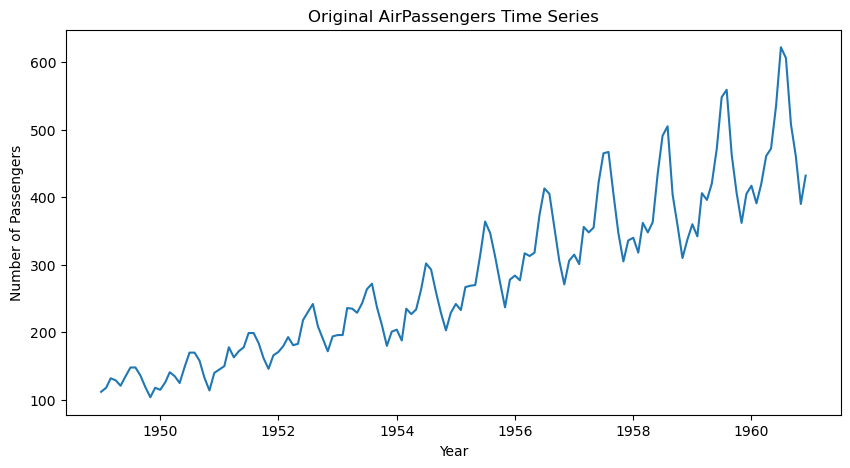

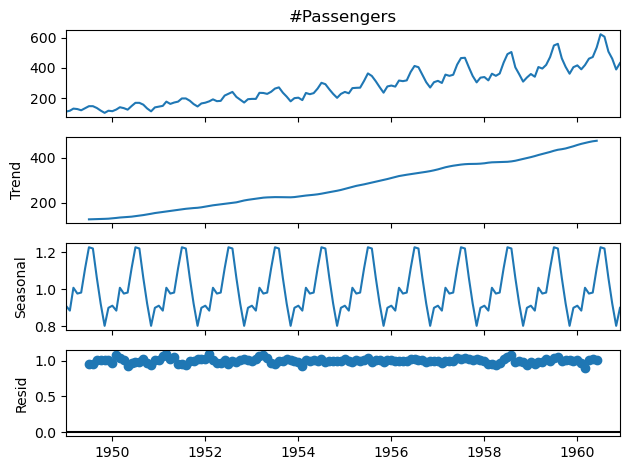

In [1]:
#6. Load a time series dataset (e.g., AirPassengers), plot the original series, and decompose it into trend, seasonality, and residual components.

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load dataset
df = pd.read_csv("AirPassengers.csv")

# Convert Month column into datetime
df['Month'] = pd.to_datetime(df['Month'])

# Set Month as index
df.set_index('Month', inplace=True)

# Plot original time series
plt.figure(figsize=(10,5))
plt.plot(df['#Passengers'])
plt.title("Original AirPassengers Time Series")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.show()

# Decompose the time series
decomposition = seasonal_decompose(df['#Passengers'], model='multiplicative')

# Plot trend, seasonality, and residuals
decomposition.plot()
plt.show()

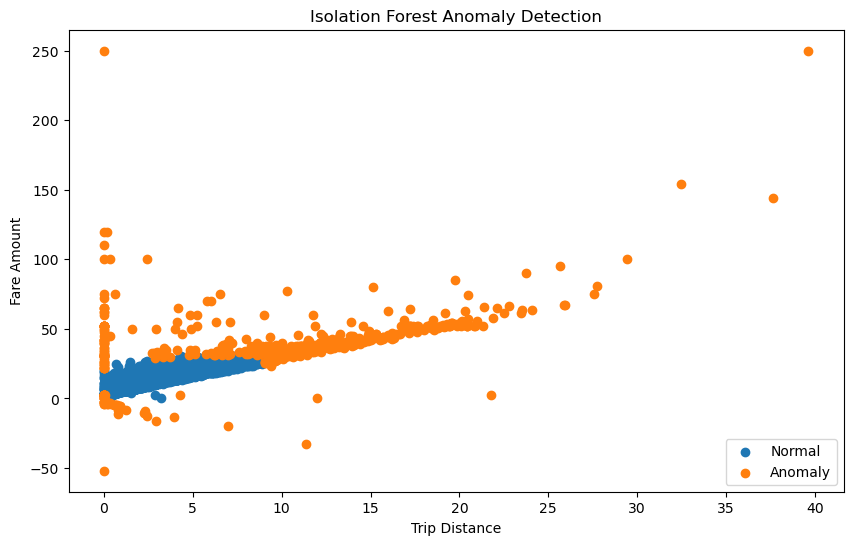

In [2]:
#7. Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to detect anomalies. Visualize the anomalies on a 2D scatter plot. 
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Load dataset
df = pd.read_csv("NYC_taxi_fare_data.csv")

# Select numerical columns
data = df[['fare_amount', 'trip_distance']]

# Remove missing values
data = data.dropna()

# Apply Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)

# Predict anomalies
data['anomaly'] = model.fit_predict(data)

# Normal points = 1
# Anomalies = -1

# Separate normal and anomalous points
normal = data[data['anomaly'] == 1]
anomaly = data[data['anomaly'] == -1]

# Plot scatter graph
plt.figure(figsize=(10,6))

# Normal data
plt.scatter(
    normal['trip_distance'],
    normal['fare_amount'],
    label='Normal'
)

# Anomalies
plt.scatter(
    anomaly['trip_distance'],
    anomaly['fare_amount'],
    label='Anomaly'
)

# Labels and title
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.title("Isolation Forest Anomaly Detection")
plt.legend()

plt.show()

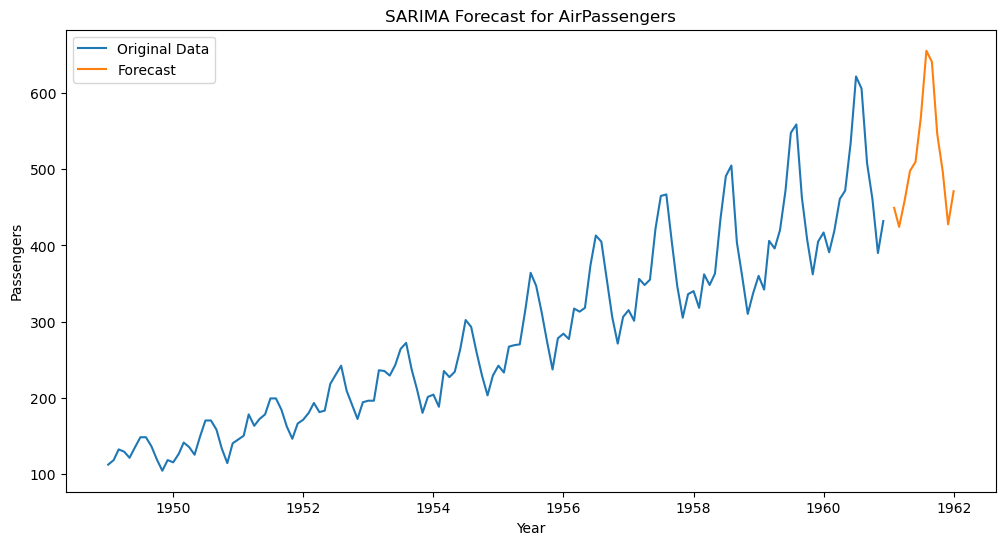

In [3]:
# 8.Train a SARIMA model on the monthly airline passengers dataset.Forecast the next 12 months and visualize the results. 
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("AirPassengers.csv")

# Convert Month column into datetime
df['Month'] = pd.to_datetime(df['Month'])

# Set Month as index
df.set_index('Month', inplace=True)

# Select target column
ts = df['#Passengers']

# Train SARIMA model
model = SARIMAX(
    ts,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

result = model.fit()

# Forecast next 12 months
forecast = result.forecast(steps=12)

# Create future dates
future_dates = pd.date_range(
    start=ts.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq='M'
)

# Plot original data
plt.figure(figsize=(12,6))
plt.plot(ts, label='Original Data')

# Plot forecast
plt.plot(future_dates, forecast, label='Forecast')

# Labels and title
plt.title("SARIMA Forecast for AirPassengers")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()

plt.show()

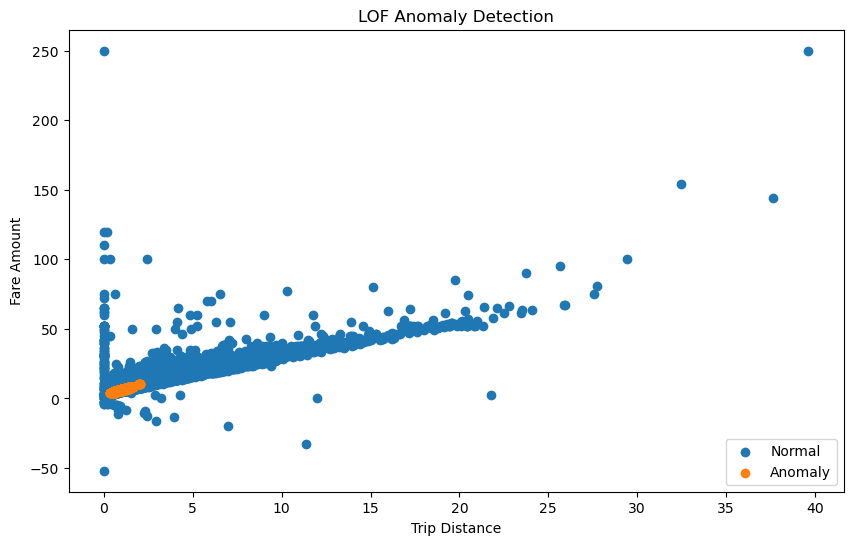

In [4]:
# 9. Apply Local Outlier Factor (LOF) on any numerical dataset to detect anomalies and visualize them using matplotlib. 

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# Load dataset
df = pd.read_csv("NYC_taxi_fare_data.csv", low_memory=False)

# Select numerical columns
data = df[['fare_amount', 'trip_distance']]

# Remove missing values
data = data.dropna()

# Apply LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

# Predict anomalies
data['anomaly'] = lof.fit_predict(data)

# Separate normal and anomaly points
normal = data[data['anomaly'] == 1]
anomaly = data[data['anomaly'] == -1]

# Plot results
plt.figure(figsize=(10,6))

# Normal points
plt.scatter(
    normal['trip_distance'],
    normal['fare_amount'],
    label='Normal'
)

# Anomaly points
plt.scatter(
    anomaly['trip_distance'],
    anomaly['fare_amount'],
    label='Anomaly'
)

# Labels and title
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.title("LOF Anomaly Detection")
plt.legend()

plt.show()

10. You are working as a data scientist for a power grid monitoring company. 
Your goal is to forecast energy demand and also detect abnormal spikes or drops in 
real-time consumption data collected every 15 minutes. The dataset includes features 
like timestamp, region, weather conditions, and energy usage. 
Explain your real-time data science workflow: 
● How would you detect anomalies in this streaming data (Isolation Forest / LOF / 
DBSCAN)? 
● Which time series model would you use for short-term forecasting (ARIMA / 
SARIMA / SARIMAX)? 
● How would you validate and monitor the performance over time? 
● How would this solution help business decisions or operations?

  - As a data scientist working for a power grid monitoring company, my main objective would be to predict future energy demand and detect unusual spikes or drops in electricity consumption in real time. Since the data is collected every 15 minutes, the system must process continuous streaming data efficiently.
  - To detect anomalies, I would mainly use Isolation Forest because it works well on large real-time datasets and can quickly identify unusual patterns in energy usage. It can help detect sudden spikes, unexpected drops, equipment failures, or power theft. I may also use Local Outlier Factor (LOF) when local behavior is important, such as comparing electricity usage within similar regions or time periods. DBSCAN can also be useful for identifying abnormal clusters or noisy patterns, but it is generally more suitable for offline analysis rather than fast real-time streaming systems.
  - For short-term forecasting, I would prefer using the SARIMAX model. Energy consumption usually contains trend and seasonality, and it is also affected by external factors like   temperature, humidity, weather conditions, holidays, and region. SARIMAX is suitable because it can handle both seasonal patterns and external variables together, making forecasts more accurate than ARIMA or SARIMA alone.
  - To validate the model, I would divide the data into training and testing sets based on time order and use rolling validation methods. Forecasting performance can be measured using metrics such as MAE, RMSE, and MAPE. For anomaly detection, I would monitor precision, recall, and false alarm rates. In production, I would continuously compare predicted energy demand with actual consumption and retrain the models whenever performance starts decreasing due to changing patterns or seasonal shifts.
  - This solution would provide several business benefits. Accurate forecasting helps the company balance electricity supply and demand efficiently, reducing wastage and operational costs. Real-time anomaly detection can quickly identify grid failures, abnormal consumption, or equipment problems before they become serious issues. It also helps operators make faster decisions, improves grid reliability, and ensures uninterrupted power supply for customers.